In [98]:
#just to draw graph.
import networkx as nx
import matplotlib.pyplot as plt

#for notebook
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [99]:
#just to draw graph.
def draw_graph_with_nx(G):
    pos = nx.spring_layout(G , iterations = 200)
    options = {"node_color" : 'white' , "alpha" : 1  , "node_size" : 2000 , "width" : 0.002,
               "font_size" : '25' , "edge_color" : 'brown' , "arrows" : True, 
              "arrowstyle" : 'Fancy,head_length = 1 , head_width = 1 , tail_width = 0.4'
    }

    labels = nx.get_node_attributes(G,"label")
    nx.draw(G,pos,labels = labels , **options)
    plt.show()

In [100]:
class DiGraph: #A graph is just a dictionary with keys as nodes and values as a list :
               #This list will have all the other nodes that have relation with key_node.
    
   
    def __init__(self):
        self.g = {}          #Graph is just a dictionary


    
    def add_node(self , node):
        #sainty check
        if node is self.g:                              #agr node self.g ma ha, yani ka koi `key` ha to wo already exist krti ha...
            raise ValueError("Node already in graph")

        self.g[node] = []                               #create a key in dictionary with `key==node` and a create a list as its value.   


    #to create relations between nodes inside the lists in `values`...
    def add_edge(self,src,dest,weight):
        #sainty checks
        if src not in self.g:
            raise ValueError("Source not present!")
        if dest not in self.g:
            raise ValueError("Destination not present!")

        #nexts contain all the list elements(values) of a key.
        nexts = self.g[src]                                   #self.g[src] will return a `list` : (value) for that key(src)
        if dest in nexts:                                     #to form an egde is to simply add the node in the list against its key.
            return                                            #if dest alrady present in that list than just return

        nexts.append((dest,weight))                           #else append it in the list.





    #just to draw graph.
    def draw_graph(self):
        G = nx.DiGraph()
        for src in self.g:
            G.add_node(src,label = src)
            for dest in self.g[src]:
                G.add_edge(src, dest[0] , weight = str(dest[1]))
                
        draw_graph_with_nx(G)

In [101]:
def dijkestra(self,src,dest):
    # Mark all nodes unvisited and store them.
    to_visit = list(  self.g.keys()   )

    print("To visit " + str(to_visit))
    
    #Set the distance to zero for our initial node and to infinity for other nodes. 
    inf = float('inf') #python for infinity

    dists = {node: inf for node in to_visit}
    dists[src] = 0
    print ("All distances " + str(dists))


    best_paths = {}
    best_paths[(src,src)] = [src]

    #let's loop
    while to_visit:
        print("-----------")
        
        #select the unvisited node with smallest distance 
        # cannot compare 'a' with 'b' , So we compare dists['a'] with dists[['b']] 
        current = min(to_visit, key = lambda node: dists[node] )
        print("Current : " + current)


        if dists[current] == inf:
            break

        #Find unvisited neighbours for current node
        nexts = self.g[current]
        unvisited_neighbours = []
        for n in nexts:
            if n[0] in to_visit:
                unvisited_neighbours.append(n)

        print("Unvisited neighbours of " + current + " : " + str(unvisited_neighbours))

        for n in unvisited_neighbours:
            label = n[0]
            dist_to = n[1]
            #get old best distance and new distance
            old_distance = dists[label]
            new_distance = dists[current] + dist_to
            #see if we are improving old best
            if new_distance < old_distance:
                print("\n Found new best path ...")
                dists[label] = new_distance

                #also save paths
                #best way to get from src to label is src --> current --> label
                path_to_current = best_paths[(src , current)][:]    #[:] #to create deep copy
                best_paths[(src,label)] = path_to_current
                best_paths[(src,label)].append(label)
                print("Previous best path to current :" , best_paths[(src,current)])
                print("Best path to :",label,":",best_paths[(src,label)])


        print("All distances " + str(dists))
        #curent is now visited
        to_visit.remove(current)



    #break 


    return best_paths[(src,dest)] , dists[dest]

DiGraph.dijkestra = dijkestra 
               

In [102]:
g = DiGraph()

nodes  = ['a','b','c','d','e','f','g','h']

for n in nodes:
    g.add_node(n) 

In [103]:
edges = [
    ('a','b',4),
    ('a','c',1),
    ('b','d',8),
    ('c','e',25),
    ('e','d',3),
    ('d','f',5),
    ('d','g',7),
    ('f','d',2),
    ('g','h',9),
]
for e in edges:
    g.add_edge(e[0],e[1],e[2])

In [104]:
import pprint
pprint.pprint(g.g)

{'a': [('b', 4), ('c', 1)],
 'b': [('d', 8)],
 'c': [('e', 25)],
 'd': [('f', 5), ('g', 7)],
 'e': [('d', 3)],
 'f': [('d', 2)],
 'g': [('h', 9)],
 'h': []}


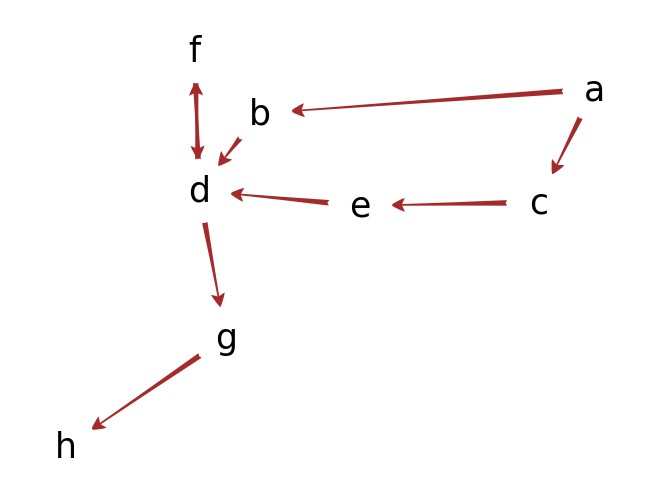

In [105]:
g.draw_graph()

In [106]:
g.dijkestra('a','d')

To visit ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
All distances {'a': 0, 'b': inf, 'c': inf, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
-----------
Current : a
Unvisited neighbours of a : [('b', 4), ('c', 1)]

 Found new best path ...
Previous best path to current : ['a']
Best path to : b : ['a', 'b']

 Found new best path ...
Previous best path to current : ['a']
Best path to : c : ['a', 'c']
All distances {'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
-----------
Current : c
Unvisited neighbours of c : [('e', 25)]

 Found new best path ...
Previous best path to current : ['a', 'c']
Best path to : e : ['a', 'c', 'e']
All distances {'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
-----------
Current : b
Unvisited neighbours of b : [('d', 8)]

 Found new best path ...
Previous best path to current : ['a', 'b']
Best path to : d : ['a', 'b', 'd']
All distances {'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f': inf, 'g': inf, 'h': in

(['a', 'b', 'd'], 12)